In [44]:
import sys
import os
import  glob
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns
import plotly.express as px


In [39]:
sys.path.append(os.path.abspath(""))
from ingest import fetch_metro_sites, fetch_tirtl_traffic

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

PARQUET_PATH = "data/phase1_baseline.parquet"
HISTORICAL_DIR = "data/historical_traffic"

BASELINE_START = "01-11-2025"
BASELINE_END = "03-03-2026"

if os.path.exists(PARQUET_PATH):
    print(print(f"Loading existing combined baseline data from {PARQUET_PATH}..."))
    df = pd.read_parquet(PARQUET_PATH)

else:
    print("Building hybrid baseline dataset from daily CSVs...")
    metro_sites = fetch_metro_sites("data/tirtl_sites.csv")
    valid_sites_str = [str(s) for s in metro_sites]

    # 1. Find all csv files oin the folder 
    all_files = glob.glob(os.path.join(HISTORICAL_DIR, "*.csv"))
    print(f"Found {len(all_files)} daily CSV files. Processing...")

    df_list = []

    # 2. Loop through each file, filter it and save the chunk
    for file in all_files:
        temp_df = pd.read_csv(file)

        # inconsitencies with cols name
        if "site" in temp_df.columns:
            temp_df = temp_df.rename(columns = {"site":"site_id"})
        if "vehicleclass" in temp_df.columns:
            temp_df = temp_df.rename(columns={"vehicleclass" : "vehicle_class"})

        temp_df["date"] = pd.to_datetime(temp_df["date"])

        # Filter historical data for the required sites classes and baseline dates
        mask = (
            (temp_df["site_id"].astype(str).isin(valid_sites_str)) &
            (temp_df["vehicle_class"].astype(str).isin(["1", "5", "6", "7"])) &
            (temp_df["date"] >= BASELINE_START) &
            (temp_df["date"] <= BASELINE_END)
        )

        filtered_chunk = temp_df.loc[mask].copy()

        # Only append if the chunk actually has data
        if not filtered_chunk.empty:
            # Drop the speed_bin col
            if "speed_bin" in filtered_chunk.columns:
                filtered_chunk = filtered_chunk.drop(columns=["speed_bin"])
            
            # Aggregate the duplicates and sum the volume
            filtered_chunk = filtered_chunk.groupby(
                ["date", "time_bin", "site_id", "heading", "vehicle_class"], as_index=False
            )["volume"].sum()

            # Memory optimization
            filtered_chunk["site_id"] = filtered_chunk["site_id"].astype("category")
            filtered_chunk["heading"] = filtered_chunk["heading"].astype("category")
            filtered_chunk["vehicle_class"] = filtered_chunk["vehicle_class"].astype("category")
            filtered_chunk["volume"] = filtered_chunk["volume"].astype("uint16")
            # Memory optimization: Convert "HH:MM" to a 15-min bin index (0 to 95)
            hours = filtered_chunk["time_bin"].astype(str).str.split(':').str[0].astype("int8")
            mins = filtered_chunk["time_bin"].astype(str).str.split(':').str[1].astype("int8")
            
            # Formula: (Hour * 4) + (Minutes / 15)
            filtered_chunk["time_bin"] = (hours * 4 + (mins // 15)).astype("int8")
            df_list.append(filtered_chunk)

    # 3. Combine all the filtred daily chunks into one master df
    if len(df_list) == 0:
        raise ValueError("Files were found, but after filtering for dates/sites/classes, exactly 0 rows were left. Check your date ranges!")
    
    print("Concatenating filtered chunks...")
    df = pd.concat(df_list, ignore_index=True)
    
    
    # 4.  Save clean and combined  dataset to parquet
    df.to_parquet(PARQUET_PATH, index=False)
    print(f"Saved complete baseline data (NOV 1 - Mar 3) to {PARQUET_PATH}")


2026-04-08 16:19:48,058 - INFO - Filtering TIRTL sites by boundary
2026-04-08 16:19:48,061 - INFO - Retained 379 active sites within metro bounding box.


Building hybrid baseline dataset from daily CSVs...
Found 120 daily CSV files. Processing...
Concatenating filtered chunks...
Saved complete baseline data (NOV 1 - Mar 3) to data/phase1_baseline.parquet


In [40]:
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
display(df.head())

Dataset shape: (8712368, 6)
Date range: 2025-11-01 to 2026-02-28


,date,time_bin,site_id,heading,vehicle_class,volume
0,2025-11-01,0,2,W,1,189
1,2025-11-01,0,2,W,5,2
2,2025-11-01,0,3,E,1,678
3,2025-11-01,0,3,E,6,1
4,2025-11-01,0,3,E,7,1


### Handling sensor failures

We check **sensor uptime** by counting the number of days each sensor reported data during the baseline period.  

- If a sensor reports data for **less than 95% of the baseline period**, we remove it entirely.  
- This ensures we only use **highly reliable sensors** for analysis, avoiding false signals in traffic trends.

Total expected days in baseline: 120
Total Sites: 298
Reliable Sites Retained (>= 95%): 253
Unreliable Sites Dropped (< 95%): 45


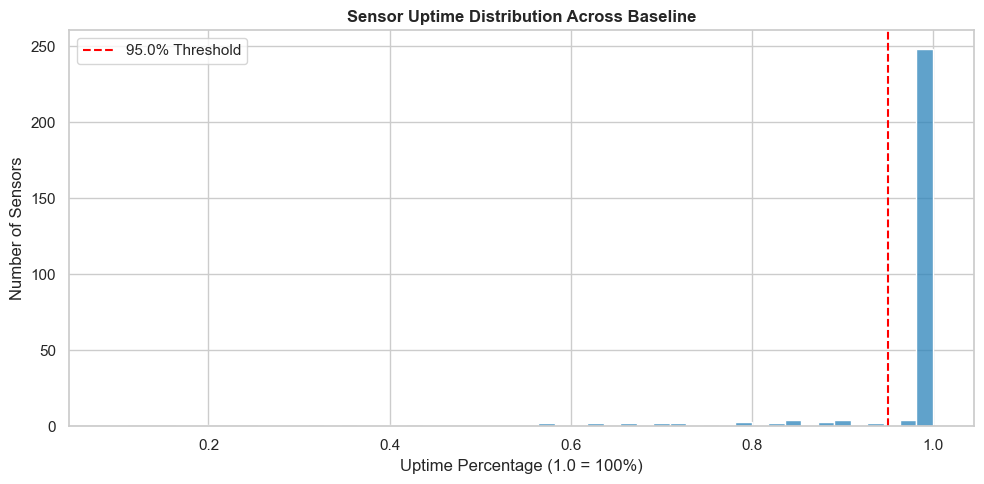

In [ ]:
total_expected_days = (df['date'].max() - df['date'].min()).days + 1
print(f"Total expected days in baseline: {total_expected_days}")

# Count unique active days per site
site_uptime = df.groupby('site_id')['date'].nunique().reset_index()
site_uptime.rename(columns={'date': 'days_active'}, inplace=True)

# Calculate uptime percentage
site_uptime['uptime_pct'] = site_uptime['days_active'] / total_expected_days

# Isolate reliable sites (>= 95% uptime)
threshold = 0.95
valid_sites = site_uptime[site_uptime['uptime_pct'] >= threshold]
dropped_sites = site_uptime[site_uptime['uptime_pct'] < threshold]

print(f"Total Sites: {len(site_uptime)}")
print(f"Reliable Sites Retained (>= 95%): {len(valid_sites)}")
print(f"Unreliable Sites Dropped (< 95%): {len(dropped_sites)}")

# VISUALIZATION: Sensor Health Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=site_uptime, x='uptime_pct', bins=50, color='#2b83ba')
plt.axvline(threshold, color='red', linestyle='--', label=f'{threshold*100}% Threshold')
plt.title('Sensor Uptime Distribution Across Baseline', fontweight='bold')
plt.xlabel('Uptime Percentage (1.0 = 100%)')
plt.ylabel('Number of Sensors')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Load the sites CSV (Adjust the path if it's in a different folder)
sites_meta = pd.read_csv("data/tirtl_sites.csv")

# Standardize column names
# Convert all column names to lowercase for easier matching
sites_meta.columns = sites_meta.columns.str.lower()

if "site" in sites_meta.columns:
    sites_meta = sites_meta.rename(columns={"site": "site_id"})
    
# Find the latitude/longitude columns (sometimes they are named lat/lon, sometimes latitude/longitude)
lat_col = 'latitude' if 'latitude' in sites_meta.columns else 'lat'
lon_col = 'longitude' if 'longitude' in sites_meta.columns else 'lon'

# Filter the metadata to ONLY include our reliable sites from the previous cell
active_sites_meta = sites_meta[sites_meta['site_id'].isin(valid_sites['site_id'])].copy()

print(f"Plotting {len(active_sites_meta)} active sensors on the map...")

# Create the interactive map
fig = px.scatter_map(
    active_sites_meta, 
    lat=lat_col, 
    lon=lon_col, 
    hover_name="site_id",
    color_discrete_sequence=["#2b83ba"], # A nice professional blue
    zoom=9, 
    height=600,
    title="Location of Reliable TIRTL Traffic Sensors (>= 95% Uptime)"
)

# Use OpenStreetMap
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

Plotting 253 active sensors on the map...


In [59]:
# Find the site with the highest total volume across the baseline
top_site = df.groupby("site_id")["volume"].sum().idxmax()
top_site_volume = df.groupby("site_id")["volume"].sum().max()

print(f"Busiest Site ID: {top_site} ({top_site_volume:,.0f} total vehicles)")

Busiest Site ID: 24 (10,734,904 total vehicles)


In [ ]:
# Filter data only for this site
